<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/Practical%20Linear%20Algebra%20for%20Data%20Science/14.Singular_Value_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 14 - Singular Value Decomposition (SVD)

Notebook ini membahas teori dekomposisi nilai singular (SVD), representasi matriks U, Sigma, dan V-transpose, serta rekonstruksi matriks peringkat rendah (low-rank approximation).

### Identitas Mahasiswa
| Detail | Identitas |
| :--- | :--- |
| **Nama** | Rahmanda Afebrio Yuris Soesatyo |
| **NIM** | 1103223024 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

# Dekomposisi Nilai Singular (SVD)


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\3402528974.py:15: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_title('$\mathbf{A}$\nThe matrix')
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\3402528974.py:18: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('$\mathbf{U}$\n(left singular vects)')
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\3402528974.py:21: SyntaxWarning: invalid escape sequence '\m'
  axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\3402528974.py:24: SyntaxWarning: invalid escape 

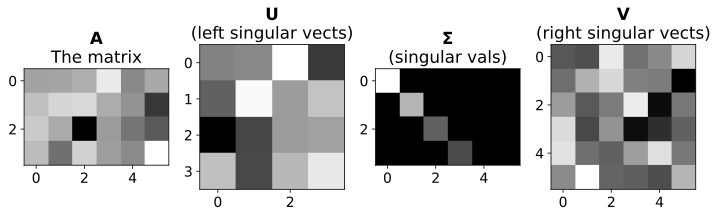

In [2]:
A = np.random.randn(4,6)

# its SVD
U,s,Vt = np.linalg.svd(A)

# create Sigma from sigma's
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# show the matrices
_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('$\mathbf{A}$\nThe matrix')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('$\mathbf{U}$\n(left singular vects)')

axs[2].imshow(S,cmap='gray',aspect='equal')
axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')

axs[3].imshow(Vt,cmap='gray',aspect='equal')
axs[3].set_title('$\mathbf{V}$\n(right singular vects)')

plt.tight_layout()
plt.savefig('Figure_14_02.png',dpi=300)
plt.show()

# SVD pada Matriks Simetris


In [3]:
A = np.random.randn(5,5)
A = A.T@A

# extract eigenvalues and singular values
eigvals = np.linalg.eig(A)[0]
sinvals = np.linalg.svd(A)[1]

# they're the same!
print(np.sort(eigvals))
print(np.sort(sinvals))

[0.01313965 1.37916883 4.70431445 6.86875665 9.90580606]
[0.01313965 1.37916883 4.70431445 6.86875665 9.90580606]


# Latihan 1

In [4]:
# create a symmetric matrix
A = np.random.randn(5,5)
A = A.T@A
# A = A+A.T # uncomment this line to repeat for A+A'

# eigendecomposition
evals,evecs = np.linalg.eig(A)

# sorting them helps the comparison!
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]



# SVD
U,s,Vt = np.linalg.svd(A)

# compare the eigenvalues and singular values
print('Eigenvalues and singular values:')
print(np.vstack((evals,s)).T)

# now compare the left and right singular vectors
print(f'\nLeft-Right singular vectors (should be zeros)')
print(np.round(U-Vt.T,10)) # remember to compare V not V^T!

# then compare singular vectors with eigenvectors
print(f'\nSingular vectors - eigenvectors (should be zeros)')
print(np.round(U-evecs,10)) # subtract and 
print(' ')                  
print(np.round(U+evecs,10)) # add for sign indeterminancy


Eigenvalues and singular values:
[[17.60431601 17.60431601]
 [ 5.01637587  5.01637587]
 [ 3.3562646   3.3562646 ]
 [ 1.15196622  1.15196622]
 [ 1.05862746  1.05862746]]

Left-Right singular vectors (should be zeros)
[[-0. -0. -0. -0. -0.]
 [-0.  0.  0.  0. -0.]
 [-0.  0.  0.  0.  0.]
 [-0.  0.  0.  0. -0.]
 [-0. -0. -0. -0. -0.]]

Singular vectors - eigenvectors (should be zeros)
[[-0. -0.  0. -0. -0.]
 [ 0. -0.  0.  0.  0.]
 [-0. -0. -0.  0.  0.]
 [-0.  0. -0. -0.  0.]
 [-0. -0.  0.  0.  0.]]
 
[[-0.34552643 -1.34700555 -1.03903311  0.73771024 -0.66511752]
 [ 0.88522284 -0.69913121 -0.64663092 -1.48606719  0.31791328]
 [-0.72841866  0.98800863 -1.47970573 -0.14087838  0.53279399]
 [-1.22064077  0.00620698  0.31602134 -1.10156666 -1.09392824]
 [-1.03751356 -0.84887691  0.46138932 -0.11871014  1.40570317]]


# Latihan 2

In [5]:
# sizes (try tall and wide)
m = 10
n = 4

# random matrix and its economy (aka reduced) SVD
A = np.random.randn(m,n)
U,s,Vt = np.linalg.svd(A,full_matrices=False)

# print sizes
print(f'Size of A:  {A.shape}')
print(f'Size of U:  {U.shape}')
print(f"Size of V': {Vt.shape}")

Size of A:  (10, 4)
Size of U:  (10, 4)
Size of V': (4, 4)


# Latihan 3

In [6]:
# The proof that |Uw|=|w| comes from expanding the vector magnitude to the dot product:
# |Uw|^2 = (Uw)'(Uw) = w'U'U'w = w'Iw = w'w = |w|^2


# empirical demonstration:
U,s,Vt = np.linalg.svd(np.random.randn(5,5))
w = np.random.randn(5,1)

# print out the norms
print( np.linalg.norm(U@w) )
print( np.linalg.norm(  w) )

1.7981084215892804
1.7981084215892802


# Latihan 4

<>:31: SyntaxWarning: invalid escape sequence '\S'
<>:31: SyntaxWarning: invalid escape sequence '\S'
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\4115500734.py:31: SyntaxWarning: invalid escape sequence '\S'
  axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')


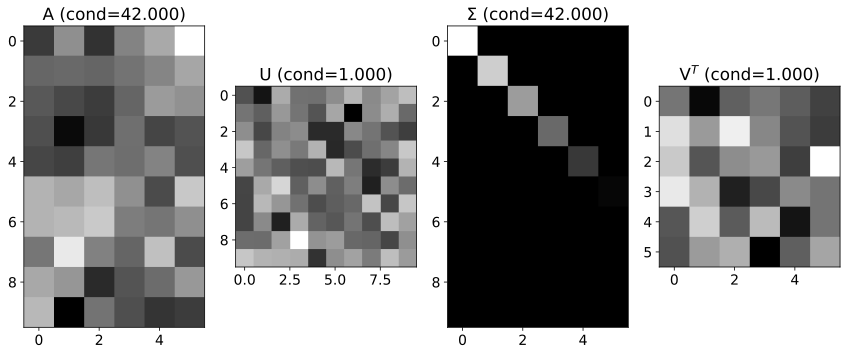

In [7]:
# create a tall matrix with specified condition number
m = 10
n = 6

condnum = 42

# create U and V from random numbers
U,_  = np.linalg.qr( np.random.randn(m,m) )
Vt,_ = np.linalg.qr( np.random.randn(n,n) )

# create singular values vector
s = np.linspace(condnum,1,np.min((m,n)))

# convert into a matrix
S = np.zeros((m,n))
np.fill_diagonal(S,s)

# create matrix
A = U@S@Vt

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray')
axs[0].set_title(f'A (cond={np.linalg.cond(A):.3f})')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title(f'U (cond={np.linalg.cond(U):.3f})')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title(f'V$^T$ (cond={np.linalg.cond(Vt):.3f})')


plt.tight_layout()
plt.savefig('Figure_14_04.png',dpi=300)
plt.show()

# Latihan 5

<>:34: SyntaxWarning: invalid escape sequence '\S'
<>:34: SyntaxWarning: invalid escape sequence '\S'
C:\Users\62812\AppData\Local\Temp\ipykernel_9916\2272684522.py:34: SyntaxWarning: invalid escape sequence '\S'
  axs[2].set_title('$\Sigma$')


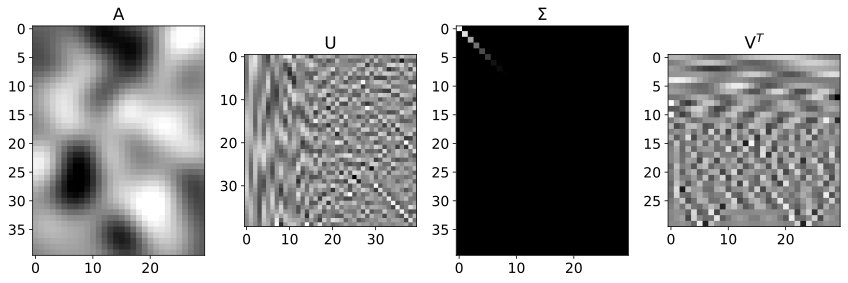

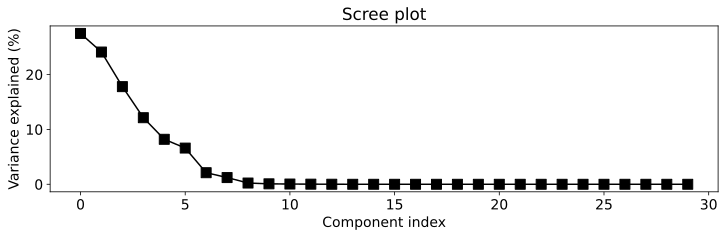

In [8]:
# create the matrix
m = 40
n = 30

# define a 2D Gaussian for smoothing
k = int((m+n)/4)
X,Y = np.meshgrid(np.linspace(-3,3,k),np.linspace(-3,3,k))
g2d = np.exp( -(X**2 + Y**2)/(k/8) )


# now for the matrix
from scipy.signal import convolve2d
A = convolve2d(np.random.randn(m,n),g2d,mode='same')


# SVD and create Sigma
U,s,Vt = np.linalg.svd(A)
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# visualize the matrices

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray', vmin=-10,vmax=10)
axs[0].set_title('A')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title('U')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title('$\Sigma$')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title('V$^T$')


plt.tight_layout()
plt.savefig('Figure_14_05a.png',dpi=300)
plt.show()


# and show the scree plot
plt.figure(figsize=(12,3))
plt.plot(100*s/np.sum(s),'ks-',markersize=10)
plt.xlabel('Component index')
plt.ylabel('Variance explained (%)')
plt.title('Scree plot')
plt.savefig('Figure_14_05b.png',dpi=300)
plt.show()

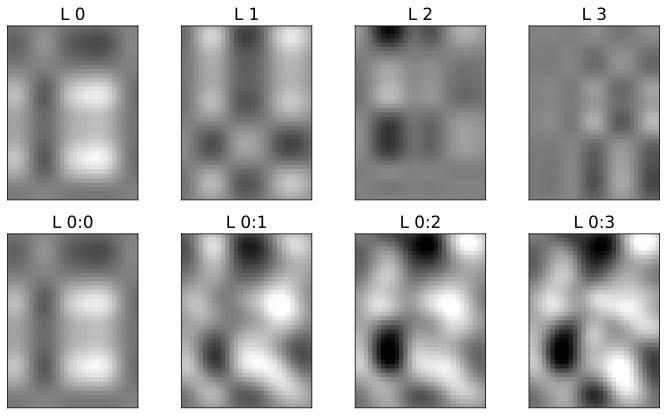

In [9]:
## now show the first N "layers" separately and summed

numLayers = 4
rank1mats = np.zeros((numLayers,m,n))


# setup the figure
_,axs = plt.subplots(2,numLayers,figsize=(10,6))

# the loop
for i in range(numLayers):
    
    # create this layer
    rank1mats[i,:,:] = np.outer(U[:,i],Vt[i,:])*S[i,i]
    
    # show this layer
    axs[0,i].imshow(rank1mats[i,:,:],cmap='gray', vmin=-10,vmax=10)
    axs[0,i].set_title(f'L {i}')
    axs[0,i].set_xticks([]), axs[0,i].set_yticks([])

    # show the cumulative sum of layers
    axs[1,i].imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray', vmin=-10,vmax=10)
    axs[1,i].set_title(f'L 0:{i}')
    axs[1,i].set_xticks([]), axs[1,i].set_yticks([])


plt.tight_layout()
plt.savefig('Figure_14_05c.png',dpi=300)
plt.show()

# Latihan 6

In [10]:
# singular matrix
A = np.random.randn(5,3) @ np.random.randn(3,5)

# its SVD
U,s,Vt = np.linalg.svd(A)

# define a threshold (tolerance) for "zero-valued" singular values
# I thought of using eps scaled by the size of A. Numpy fixed this to 10^-15, 
# which means it is not adapted to different computer precisions.
tol = np.finfo(float).eps * np.max(A.shape)

# invert the supra-threshhold sigma's
sInv = np.zeros_like(s)
sInv[s>tol] = 1/s[s>tol]

# reconstruct
S = np.zeros_like(A)
np.fill_diagonal(S,sInv)
Apinv = Vt.T @ S @ U.T

# compare to pinv()
ApinvNp = np.linalg.pinv(A)

print(np.round( ApinvNp - Apinv ,5))

[[-0.  0. -0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [-0.  0.  0.  0.  0.]]


In [11]:
# check the source code for pinv
??np.linalg.pinv

# Latihan 7

In [12]:
# left-inverse
A = np.random.randn(6,4)

# explicit left inverse
Linv = np.linalg.inv(A.T@A)@A.T

# pinv
Apinv = np.linalg.pinv(A)

# compare
print(np.round( Linv - Apinv ,5))

[[ 0.  0.  0. -0.  0. -0.]
 [ 0.  0. -0.  0. -0. -0.]
 [-0. -0.  0.  0.  0. -0.]
 [ 0.  0. -0.  0.  0.  0.]]


In [13]:
# right-inverse
A = np.random.randn(4,6)

# explicit right inverse
Rinv = A.T@np.linalg.inv(A@A.T)

# pinv
Apinv = np.linalg.pinv(A)

# compare
print(np.round( Rinv - Apinv ,5))

[[ 0. -0.  0. -0.]
 [-0.  0.  0. -0.]
 [-0. -0. -0.  0.]
 [-0.  0.  0. -0.]
 [ 0.  0.  0. -0.]
 [ 0. -0.  0. -0.]]


# Latihan 8

In [14]:
# the matrix (from chapter 12)
M = np.array([ [-1,1],
               [-1,2] ])

# its eigendecomposition
evals,evecs = np.linalg.eig(M)
l = evals[1]     # extract lambda1 for convenience
v = evecs[:,[1]] # extract v1 for convenience

LHS = M@v
RHS = l*v

# print out the two sides (as row vectors for visual convenience)
print(LHS.T)
print(RHS.T)

[[-0.57735027 -1.51152263]]
[[-0.57735027 -1.51152263]]


In [15]:
# pinv(v)
vPinv = np.linalg.pinv(v)

# check
vPinv@v

array([[1.]])

In [16]:
# first equation
LHS = vPinv @ M @ v
RHS = l * vPinv @ v

# these results are scalars (quadratic form)
print(LHS)
print(RHS)

[[1.61803399]]
[[1.61803399]]


In [17]:
# second equation
LHS = M @ v @ vPinv
RHS = l * v @ vPinv

# these results are matrices
print(LHS), print(' ')
print(RHS)

[[0.20601133 0.53934466]
 [0.53934466 1.41202266]]
 
[[0.20601133 0.53934466]
 [0.53934466 1.41202266]]


---

## Ringkasan dan Pandangan (Summary and Outlook)

### Ringkasan Bab 14

Kita telah mempelajari formulasi SVD untuk mendekomposisi matriks apa saja menjadi tiga komponen utama. SVD sangat kuat untuk analisis reduksi dimensi karena nilai singular diurutkan berdasarkan kepentingannya.

### Pandangan ke Depan

Bab berikutnya akan mengaplikasikan Eigendecomposition dan SVD dalam algoritma PCA (Principal Component Analysis) dan kompresi citra.
